In [8]:
from loader import load_data

(x, y_gt) = load_data(filename="2d_classification_single_neuron.csv")

print("x:", x)
print("y_gt:", y_gt)

x: [[-0.89471091  0.85793277]
 [ 0.32661227 -0.10991945]
 [ 0.65323643  0.31083676]
 [ 0.37978177 -0.24913824]
 [ 0.51915753  0.75510596]
 [-0.49244853  0.98940665]
 [ 0.9675439  -0.26420331]
 [ 0.41242988 -0.74813264]
 [-0.96673248 -0.39436815]
 [ 0.54796375 -0.07879523]
 [ 0.40816126 -0.98972726]
 [ 0.61687688  0.56854628]
 [ 0.81726717  0.0107966 ]
 [-0.64591095  0.08446858]
 [ 0.67036125 -0.45247809]
 [-0.05767461  0.40890334]
 [ 0.10093381  0.36701997]
 [ 0.20756759  0.49568099]
 [ 0.06948646  0.10283545]
 [ 0.20141267 -0.94973283]
 [ 0.61278705 -0.8969228 ]
 [-0.68177752 -0.71196942]
 [-0.29749021 -0.12377133]
 [-0.5564142  -0.44435136]
 [ 0.2652686   0.13827281]
 [ 0.7658653   0.05601265]
 [-0.56261382 -0.94003346]
 [ 0.63153279  0.70429594]
 [-0.00497007 -0.23808578]
 [ 0.38691012  0.33179337]
 [-0.98184646  0.81747338]
 [ 0.10840287 -0.81073718]
 [-0.68099959  0.85839978]
 [ 0.26402324 -0.98027001]
 [ 0.06601267 -0.93742652]
 [-0.26591168  0.44258014]
 [ 0.92322315  0.36951395

a) Start by making a color coded scatter plot of the data in
”2d_classification_single_neuron.csv”, with the two input data variables on the xand y-axes and the class value color coded.

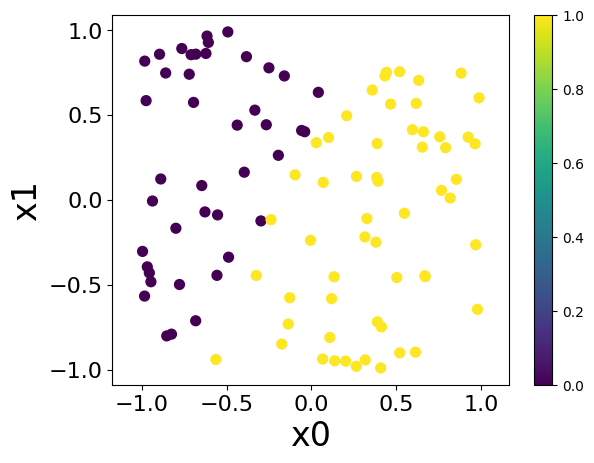

In [9]:
from plotting import plot_data_2d

plot_data_2d(x, y_gt)

b) Define a neuron capable of handling multi-dimensional inputs. Specifically, let
the weights now be a vector of equal length as the input, while the bias remains a
single floating point number. The output can be calculated as 𝑦 =
sigmoid(𝑥@𝑤 + 𝑏), using the Pythonic shorthand for matrix multiplication. Make
a color coded scatter plot of the output of the randomly initialized neuron.

In [10]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neuron_2d(w, b, x):
    """Artificial neuron for multidimensional classification."""
    return sigmoid(x @ w + b)

In [11]:
from numpy.random import default_rng

rng = default_rng()
w = rng.standard_normal(size=(2,))
b = rng.standard_normal()

y_p = neuron_2d(w, b, x)

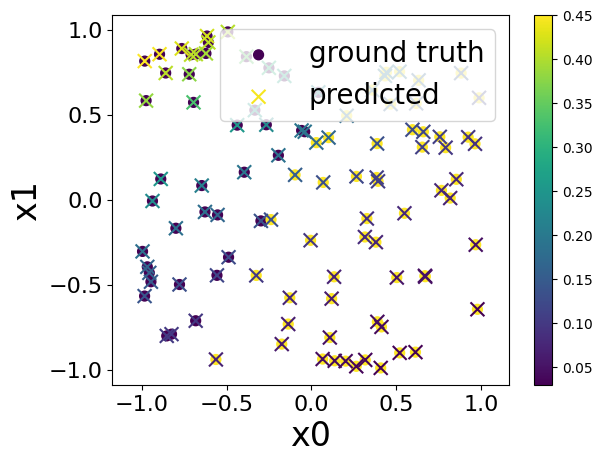

In [12]:
from plotting import plot_pred_2d
plot_pred_2d(x, y_gt, y_p)

c) Update the training loop defined in problem 1 to train this two-dimensional
neuron, and plot the evolution of the error and the final output of the trained
neuron. Hint: use 𝜂 ≈ 0.1

In [13]:
num_samples          = len(x)
num_train_iterations = 10_000
eta                  = 0.1
errors               = []

for i in range(num_train_iterations):
    selected      = rng.integers(0, num_samples)
    x_selected    = x[selected]
    y_gt_selected = y_gt[selected]

    y_p_selected  = neuron_2d(w, b, x_selected)

    error = y_p_selected - y_gt_selected
    sigmoid_prime = y_p_selected * (1 - y_p_selected)

    w = w - eta * 2 * error * sigmoid_prime * x_selected
    b = b - eta * 2 * error * sigmoid_prime

    errors.append(error ** 2)


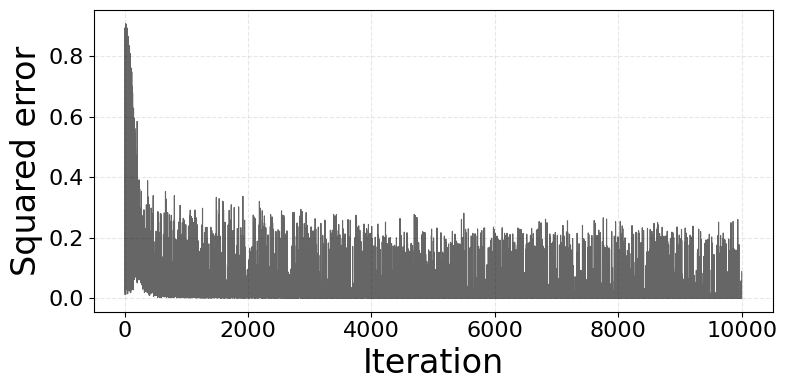

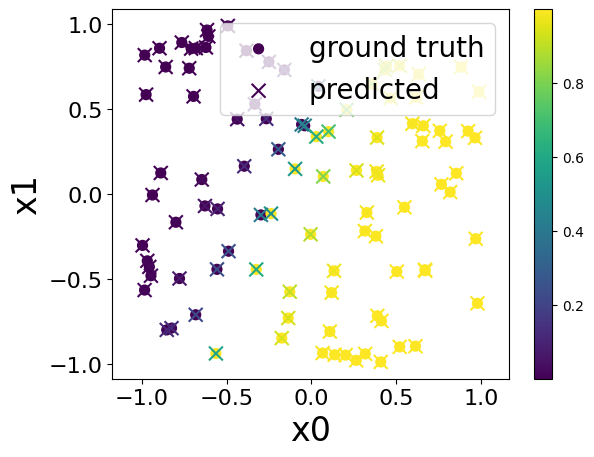

In [14]:
from plotting import plot_errors
plot_errors(errors)

plot_pred_2d(x, y_gt, y_p=neuron_2d(w, b, x))